<a href="https://colab.research.google.com/github/University02/MachineLearning/blob/main/MachineLearning3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Progetto di Machine Learning: Predizione Costo Polizza Assicurativa**

Studenti: Gioacchino Sabatini e Miriam Mirabile

Dataset: Insurance (Kaggle)

Obiettivo: Costruire un modello di regressione capace di stimare il costo della polizza sanitaria a partire dalle caratteristiche anagrafiche e sanitarie;

Il notebook segue le 5 fasi richieste: Exploratory Data Analysis, Pre-processing, Addestramento, Validazione e Risposte del test-set.

**1. Exploratory Data Analysis (EDA)**
In questa fase esaminiamo la struttura del dataset. Dal metodo `info()` verifichiamo l'assenza di valori nulli. Attraverso gli istogrammi analizziamo la distribuzione delle variabili numeriche (notando che i costi sono sbilanciati verso valori bassi). La Scatter Matrix con `hue="smoker"` ci rivela immediatamente un pattern cruciale: lo status di fumatore è la variabile che più di tutte spinge i costi verso la fascia alta.

--- Prime 5 righe del dataset ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Informazioni sul dataset (tipi di dato e valori nulli) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Statistiche descrittive (media, min, max, ecc.) ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


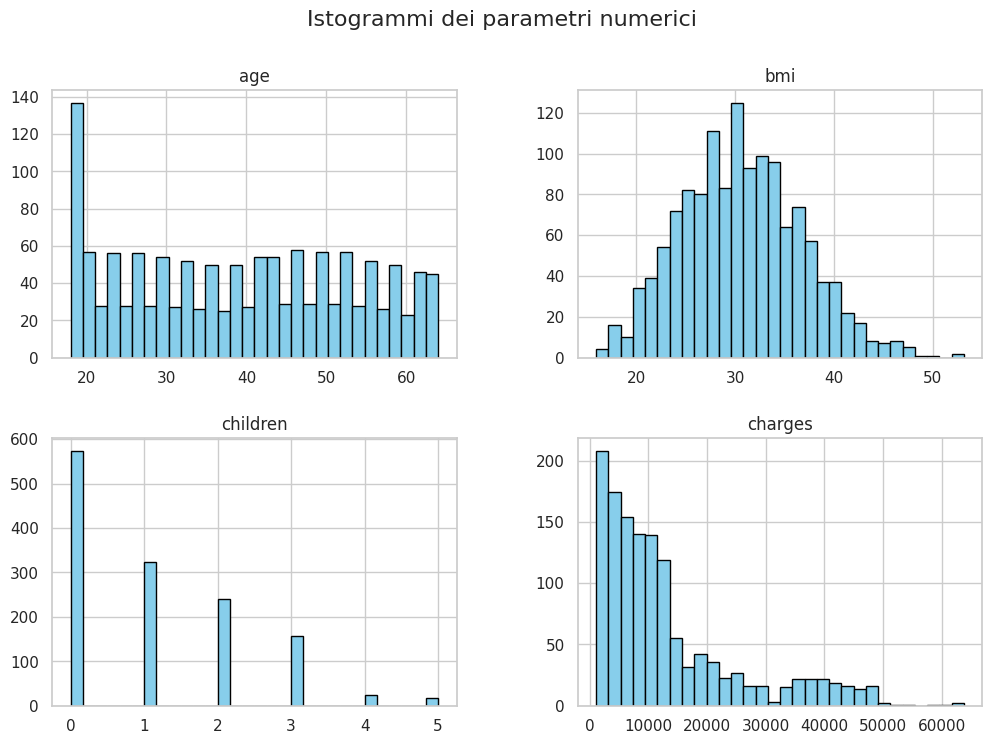

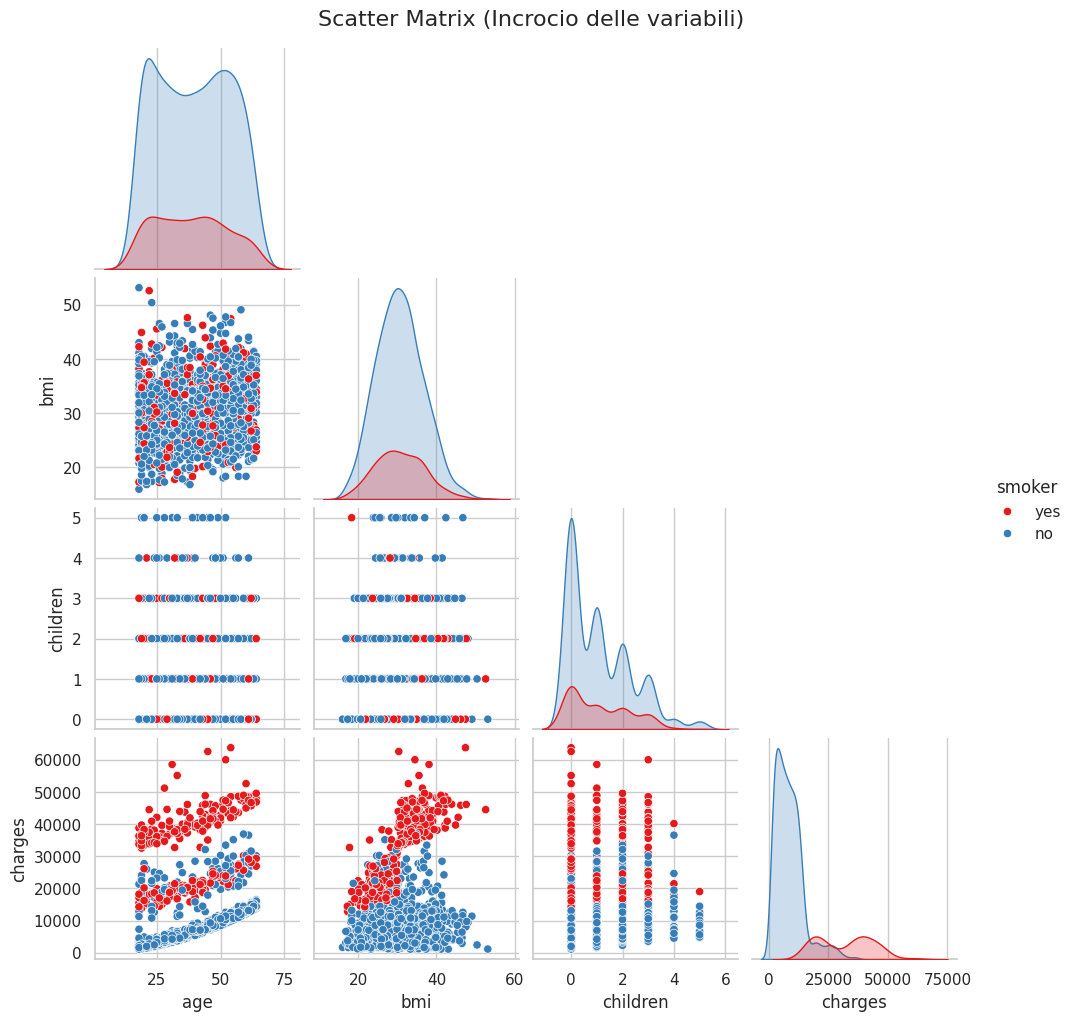

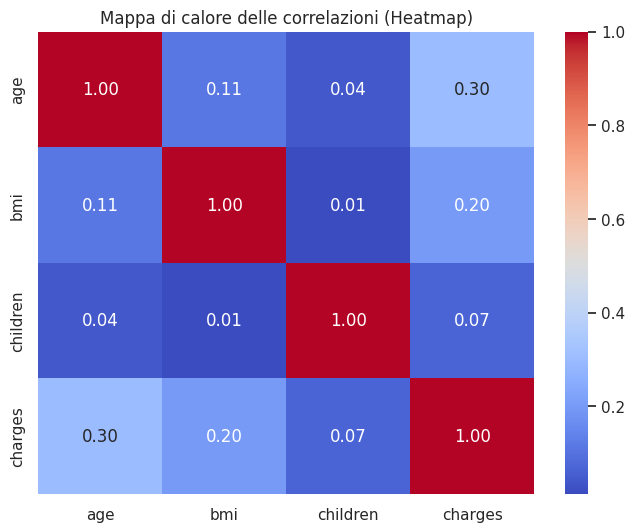

In [1]:
# Importiamo le librerie fondamentali per l'analisi dei dati
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARICAMENTO DATI E VISUALIZZAZIONE INIZIALE
# Usiamo un link diretto al file CSV per comodità
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print("--- Prime 5 righe del dataset ---")
display(df.head())

print("\n--- Informazioni sul dataset (tipi di dato e valori nulli) ---")
df.info()

print("\n--- Statistiche descrittive (media, min, max, ecc.) ---")
display(df.describe())

# 2. ISTOGRAMMI DEI PARAMETRI
# Impostiamo uno stile carino per i grafici
sns.set_theme(style="whitegrid")

# Creiamo gli istogrammi per le variabili numeriche (età, bmi, figli, costo)
df.hist(bins=30, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Istogrammi dei parametri numerici", fontsize=16)
plt.show()

# 3. SCATTER MATRIX (Matrice di dispersione)
# Usiamo il pairplot di seaborn.
# CHICCA: Aggiungiamo 'hue="smoker"' per colorare i punti in base a chi fuma.
# Questo farà un'ottima impressione sulla prof, perché mostrerà subito una cosa importante!
sns.pairplot(df, hue="smoker", palette="Set1", corner=True)
plt.suptitle("Scatter Matrix (Incrocio delle variabili)", y=1.02, fontsize=16)
plt.show()

# EXTRA: Matrice di Correlazione (Molto apprezzata nei progetti)
plt.figure(figsize=(8, 6))
# Calcoliamo la correlazione solo sulle colonne numeriche
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mappa di calore delle correlazioni (Heatmap)")
plt.show()

**2. Pre-processing e Feature Selection**
Gli algoritmi richiedono dati numerici. Pertanto, mappiamo le variabili binarie (sesso, fumatore) in 0/1 e usiamo il One-Hot Encoding per le regioni. Dalla matrice di correlazione calcolata dopo l'encoding si evince che le regioni hanno un impatto trascurabile sui costi (correlazione ≈0 con charges), mentre lo status di fumatore è il predittore dominante; procedo quindi a rimuovere le regioni per semplificare il modello (Feature Selection).
Nota fondamentale: Lo split in Training e Test set viene effettuato prima della standardizzazione (Scaling). Questo previene il fenomeno del Data Leakage, assicurando che nessuna informazione del test set "inquini" la media e la varianza usate per scalare il training set.

Colonne dopo la trasformazione:
 ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


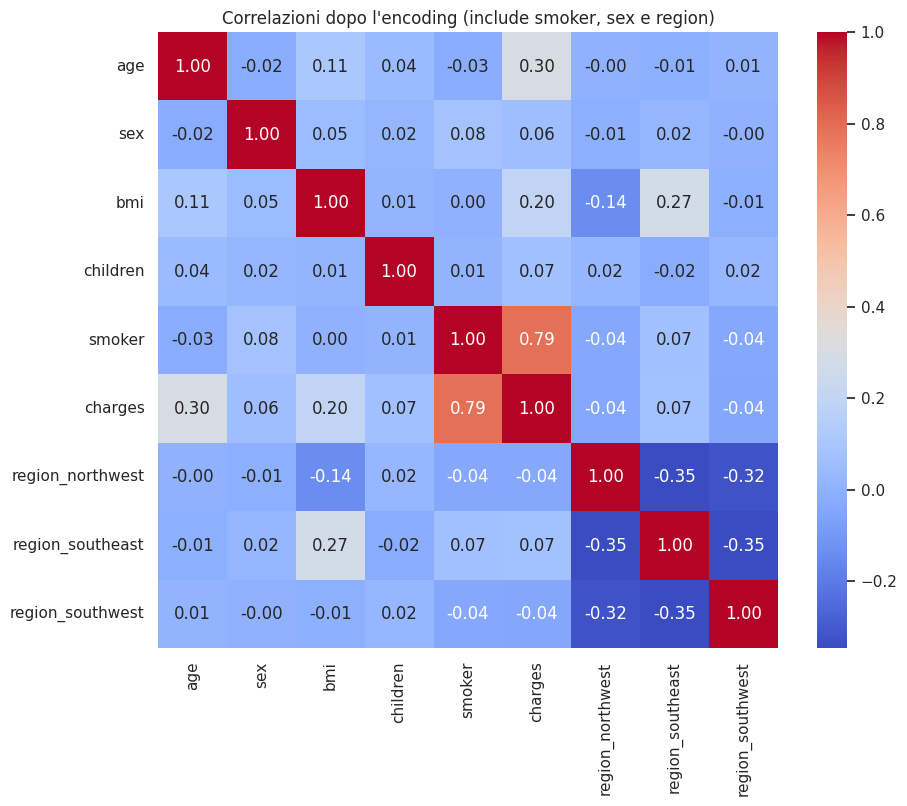


Correlazione di ciascuna variabile con 'charges':
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

Features selezionate per il modello:
 ['age', 'sex', 'bmi', 'children', 'smoker']

--- Prime 5 righe di X_train (pronte per l'addestramento) ---


,age,sex,bmi,children,smoker
560,0.472227,0,-1.756525,0.734336,0
1285,0.543313,0,-1.033082,-0.911192,0
1142,0.898745,0,-0.943687,-0.911192,0
969,-0.025379,0,0.622393,3.202629,0
486,1.040918,0,-1.504893,1.557100,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. TRASFORMAZIONE (Encoding delle variabili categoriche)
# Mappiamo le variabili binarie
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# Applichiamo il One-Hot Encoding per 'region'
# drop_first=True evita il problema della "dummy trap" (collinearità perfetta)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("Colonne dopo la trasformazione:\n", df.columns.tolist())

# --- Heatmap DOPO l'encoding: ora smoker, sex e region sono numeriche ---
# Serve a giustificare visivamente DUE decisioni:
#  1) il ruolo dominante di 'smoker' (la correlazione più alta con charges);
#  2) l'eliminazione di 'region' (correlazioni ~0 con charges).
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlazioni dopo l'encoding (include smoker, sex e region)")
plt.show()

# Focus: correlazione di ogni variabile con il target 'charges', ordinata
print("\nCorrelazione di ciascuna variabile con 'charges':")
print(df.corr(numeric_only=True)['charges'].sort_values(ascending=False))

# 2. SELEZIONE DELLE FEATURES (Feature Selection)
# Separiamo le variabili indipendenti (X) dalla variabile da predire (y)
# Eliminiamo le colonne create da 'region' perché la heatmap post-encoding ci ha mostrato che
# non hanno impatto significativo sul costo (charges).
X = df.drop(['charges', 'region_northwest', 'region_southeast', 'region_southwest'], axis=1)
y = df['charges']

print("\nFeatures selezionate per il modello:\n", X.columns.tolist())


# DIVIDIAMO IL DATASET (Fondamentale farlo PRIMA dello scaling per evitare Data Leakage)
# Riserviamo l'80% per addestrare il modello e il 20% per validarlo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

# 3. SCALING (Standardizzazione)
# Inizializziamo lo scaler
scaler = StandardScaler()

# Selezioniamo solo le colonne numeriche continue (non tocchiamo smoker o sex che sono 0/1)
colonne_da_scalare = ['age', 'bmi', 'children']

# Calcoliamo media e varianza (fit) e trasformiamo i dati sul TRAINING SET
X_train[colonne_da_scalare] = scaler.fit_transform(X_train[colonne_da_scalare])

# Trasformiamo il TEST SET usando i parametri calcolati sul train set
X_test[colonne_da_scalare] = scaler.transform(X_test[colonne_da_scalare])

print("\n--- Prime 5 righe di X_train (pronte per l'addestramento) ---")
display(X_train.head())

**3. Addestramento e ricerca Iper-parametri**
Per l'addestramento ho scelto di confrontare tre modelli: Linear Regression (come baseline), Ridge Regression (per testare la regolarizzazione) e Random Forest Regressor (per relazioni non lineari).
Invece di sacrificare una parte dei dati per un validation set fisso, utilizzo la K-Fold Cross Validation (cv=5) tramite `GridSearchCV`. Questo permette di trovare gli iper-parametri ottimali (es. l'`alpha` per la Ridge e `n_estimators` per il Random Forest) massimizzando l'affidabilità del modello.

In [3]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("Inizio fase di addestramento e ricerca iper-parametri...\n")

# 1. MODELLO 1: Linear Regression (Modello Base)
# Non ha iper-parametri particolari, lo addestriamo direttamente
lr = LinearRegression()
lr.fit(X_train, y_train)
print("✅ Linear Regression addestrata con successo.")

# 2. MODELLO 2: Ridge Regression
# Definiamo la griglia degli iper-parametri da esplorare
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Inizializziamo GridSearchCV con 5-fold cross-validation
# 'r2' (R-quadro) è la metrica per capire quanto il modello spiega bene i dati
ridge = Ridge()
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

print(f"✅ Ridge Regression addestrata. Miglior iper-parametro (alpha): {grid_ridge.best_params_['alpha']}")


# 3. MODELLO 3: Random Forest Regressor
# Definiamo la griglia degli iper-parametri
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Numero di alberi nel bosco
    'max_depth': [3, 5, 10, None]   # Profondità degli alberi
}

rf = RandomForestRegressor(random_state=42)
# Eseguiamo la Grid Search con Cross Validation
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1) # n_jobs=-1 usa tutti i processori
grid_rf.fit(X_train, y_train)

print(f"✅ Random Forest addestrata. Migliori iper-parametri: {grid_rf.best_params_}")

# Salviamo i modelli migliori trovati per il punto successivo
best_ridge = grid_ridge.best_estimator_
best_rf = grid_rf.best_estimator_

Inizio fase di addestramento e ricerca iper-parametri...

✅ Linear Regression addestrata con successo.
✅ Ridge Regression addestrata. Miglior iper-parametro (alpha): 1.0
✅ Random Forest addestrata. Migliori iper-parametri: {'max_depth': 3, 'n_estimators': 100}


**Decision Tree Regressor**
Includo anche il Decision Tree singolo per un confronto didattico. Essendo un modello fortemente prono all'overfitting (tende a memorizzare il training set), sfrutto la GridSearch per applicare tecniche di pruning, limitando la `max_depth` (profondità massima) e forzando un numero minimo di campioni per lo split dei nodi (`min_samples_split`).

In [4]:
# Abbiamo implementato anche il Decision Tree Regressor per confrontare
# l'approccio ad albero singolo con il metodo ensemble della Random Forest
from sklearn.tree import DecisionTreeRegressor

# 4. MODELLO 4: Decision Tree Regressor
# Definiamo la griglia degli iper-parametri
param_grid_dt = {
    'max_depth': [3, 5, 10, None],       # Profondità dell'albero
    'min_samples_split': [2, 5, 10, 20]  # Numero minimo di campioni per dividere un nodo
}

dt = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='r2')
grid_dt.fit(X_train, y_train)

print(f"✅ Decision Tree addestrato. Migliori iper-parametri: {grid_dt.best_params_}")

# Salviamo il modello migliore
best_dt = grid_dt.best_estimator_

✅ Decision Tree addestrato. Migliori iper-parametri: {'max_depth': 3, 'min_samples_split': 2}


**4. Validazione e Confronto Modelli**
Trattandosi di un task di Regressione (predizione di un costo continuo), la Confusion Matrix non è matematicamente applicabile in quanto metrica per task di Classificazione. Procedo quindi a valutare le predizioni sul Test Set utilizzando MAE, RMSE e R-quadro.
Il Random Forest si conferma il modello migliore superando i modelli lineari, mentre il confronto con il Decision Tree singolo dimostra chiaramente i benefici della tecnica Ensemble nel ridurre la varianza.

--- Tabella di Confronto tra Modelli sul Test Set ---


,MAE,RMSE,R2
Modello,,,
Random Forest,2726.619717,4550.352907,0.866629
Decision Tree,2865.637810,4776.261075,0.853057
Linear Regression,4213.484798,5829.172930,0.781130
Ridge Regression,4225.319273,5832.601077,0.780873


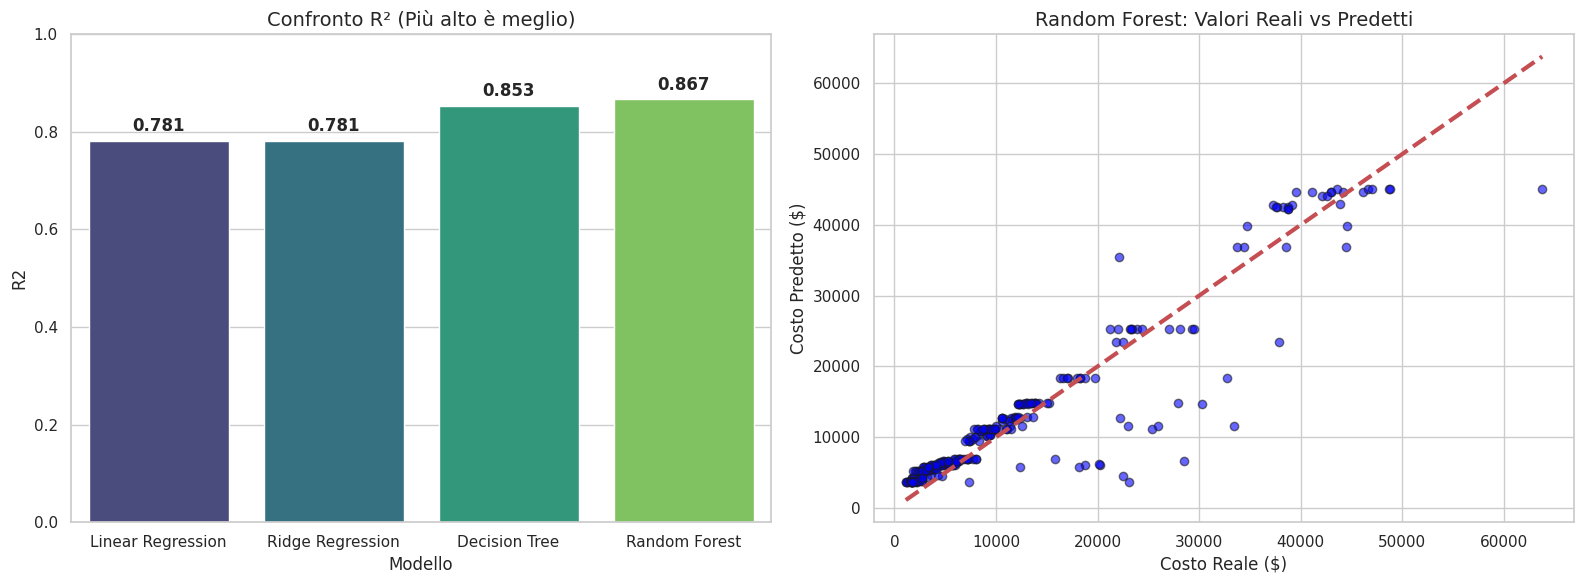

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. FUNZIONE PER CALCOLARE LE METRICHE
def valuta_modello(y_true, y_pred, nome_modello):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Modello': nome_modello, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# 2. GENERIAMO LE PREDIZIONI SUL TEST SET PER TUTTI I MODELLI
pred_lr = lr.predict(X_test)
pred_ridge = best_ridge.predict(X_test)
pred_dt = best_dt.predict(X_test)
pred_rf = best_rf.predict(X_test)

# 3. CREIAMO UNA TABELLA DI CONFRONTO
risultati = [
    valuta_modello(y_test, pred_lr, 'Linear Regression'),
    valuta_modello(y_test, pred_ridge, 'Ridge Regression'),
    valuta_modello(y_test, pred_dt, 'Decision Tree'),
    valuta_modello(y_test, pred_rf, 'Random Forest')
]

df_risultati = pd.DataFrame(risultati).set_index('Modello')
print("--- Tabella di Confronto tra Modelli sul Test Set ---")
display(df_risultati.sort_values(by='R2', ascending=False))

# 4. VISUALIZZAZIONE DEI RISULTATI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico A: Confronto dell'R-quadro tra i modelli
sns.barplot(x=df_risultati.index, y=df_risultati['R2'], hue=df_risultati.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Confronto R² (Più alto è meglio)', fontsize=14)
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_risultati['R2']):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Grafico B: Predizioni vs Valori Reali per il Modello Migliore (Assumiamo Random Forest)
axes[1].scatter(y_test, pred_rf, alpha=0.6, color='blue', edgecolor='k')
# Disegniamo la linea rossa ideale (dove predizione = realtà)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
axes[1].set_title('Random Forest: Valori Reali vs Predetti', fontsize=14)
axes[1].set_xlabel('Costo Reale ($)')
axes[1].set_ylabel('Costo Predetto ($)')

plt.tight_layout()
plt.show()

In [6]:
# RISPOSTE DEL TEST SET
import pandas as pd

# Creiamo un DataFrame che affianca i valori reali alle predizioni del nostro modello migliore (Random Forest)
df_risposte = pd.DataFrame({
    'Costo_Reale_USD': y_test.round(2),
    'Predizione_Modello_USD': pred_rf.round(2),
    'Errore_Assoluto_USD': abs(y_test - pred_rf).round(2)
})

# Stampiamo a video le prime 10 risposte per mostrare il risultato
print("--- Anteprima delle risposte del Test Set (Prime 10 righe) ---")
display(df_risposte.head(10))

# Salviamo le risposte in un file CSV scaricabile
nome_file = 'risposte_test_set_assicurazione.csv'
df_risposte.to_csv(nome_file, index=False)
print(f"\n✅ File '{nome_file}' generato con successo e pronto per la consegna!")

--- Anteprima delle risposte del Test Set (Prime 10 righe) ---


,Costo_Reale_USD,Predizione_Modello_USD,Errore_Assoluto_USD
764,9095.07,10177.53,1082.46
887,5272.18,6039.79,767.61
890,29330.98,25250.51,4080.47
1293,9301.89,10328.79,1026.90
259,33750.29,36901.58,3151.29
1312,4536.26,6546.00,2009.74
899,2117.34,3703.97,1586.63
752,14210.54,14886.76,676.22
1286,3732.63,5356.51,1623.89
707,10264.44,11104.78,840.34



✅ File 'risposte_test_set_assicurazione.csv' generato con successo e pronto per la consegna!
